# Implementation of Generative Forecasting using Joint Probability Models on KS PDE

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg
import sys
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim

In [3]:
L = 50.0
N = 200
dx = L/N
dt = 0.1
n_steps = int(4e6)     #No of Samples to be generated

In [5]:
x = np.linspace(-25, 25, N, endpoint=False)
dataset = np.zeros((n_steps, N))

rng = np.random.default_rng(seed=42)
u_current = np.zeros(N)

# Excite all 7 linearly unstable modes with random amplitudes and phases
for n_mode in range(1, 8):
    k = 2 * np.pi * n_mode / L
    amp   = rng.standard_normal()
    phase = rng.uniform(0, 2 * np.pi)
    u_current += amp * np.sin(k * x + phase)

u_current *= 0.1   # small amplitude so linear instability drives initial growth
dataset[0] = u_current

In [6]:
'''
x = np.linspace(-25, 25, N, endpoint=False)
dataset = np.zeros((n_steps, N))
u_current = np.sin(x) * np.exp(-((x - 10)**2) / 2)
dataset[0] = u_current
'''
L_matrix = np.zeros((N, N))
for i in range(N):
    #Below calculation of indices to enforce the periodic boundary condition. 
    i_minus_2 = (i - 2) % N
    i_minus_1 = (i - 1) % N
    i_plus_1 = (i + 1) % N
    i_plus_2 = (i + 2) % N
    
    L_matrix[i, i_minus_1] -= 1.0 / (dx**2)
    L_matrix[i, i] -= -2.0 / (dx**2)
    L_matrix[i, i_plus_1] -= 1.0 / (dx**2)
    L_matrix[i, i_minus_2] -= 1.0 / (dx**4)
    L_matrix[i, i_minus_1] -= -4.0 / (dx**4)
    L_matrix[i, i] -= 6.0 / (dx**4)
    L_matrix[i, i_plus_1] -= -4.0 / (dx**4)
    L_matrix[i, i_plus_2] -= 1.0 / (dx**4)

In [7]:
Identity = np.eye(N)
Matrix_A = Identity - (0.5 * dt) * L_matrix
Matrix_B = Identity + (0.5 * dt) * L_matrix

In [8]:
def calc_nonlinear_term(u):
    u_squared = 0.5 * u**2
    derivative = (np.roll(u_squared,-1) - np.roll(u_squared,1))/(2 * dx)
    return -derivative

In [9]:
NonLinear_current = calc_nonlinear_term(u_current)
RHS_vector = np.dot(Matrix_B, u_current) + dt * NonLinear_current
u_next = scipy.linalg.solve(Matrix_A, RHS_vector)

dataset[1] = u_next
u_prev = u_current
u_current = u_next

In [ ]:
print("Starting CN-AB2 time integration...")

for n in range(2, n_steps):
    NonLinear_n = calc_nonlinear_term(u_current)
    NonLinear_n_minus_1 = calc_nonlinear_term(u_prev)
    #Here for the Non-Linear (Non-Stiff) term, we use the Adam-BashForth 2 step method
    RHS_vector = np.dot(Matrix_B, u_current) + dt * (1.5 * NonLinear_n - 0.5 * NonLinear_n_minus_1)
    u_next = scipy.linalg.solve(Matrix_A, RHS_vector)
    dataset[n] = u_next
    u_prev = u_current
    u_current = u_next
    if n % 50000 == 0:
        print(f"Completed {n} time steps...")

print("Simulation finished successfully!")
np.save("ks_dataset_imex.npy", dataset)

Starting CN-AB2 time integration...
Completed 50000 time steps...
Completed 100000 time steps...
Completed 150000 time steps...
Completed 200000 time steps...
Completed 250000 time steps...
Completed 300000 time steps...
Completed 350000 time steps...
Completed 400000 time steps...
Completed 450000 time steps...
Completed 500000 time steps...
Completed 550000 time steps...
Completed 600000 time steps...
Completed 650000 time steps...
Completed 700000 time steps...
Completed 750000 time steps...
Completed 800000 time steps...
Completed 850000 time steps...
Completed 900000 time steps...
Completed 950000 time steps...


In [14]:
dataset = np.load("/kaggle/input/datasets/theredatom/ks-1d-pde/ks_dataset_imex.npy")

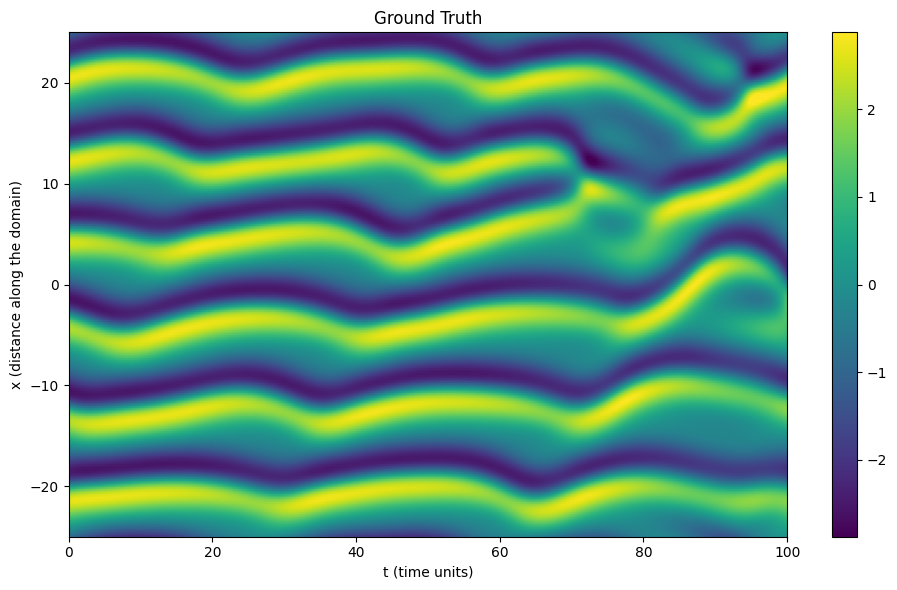

In [15]:
data_slice=dataset[int(1e6):int(1e6)+1000:]
plot_data=data_slice.T

dt=0.1
x_min,x_max=-25,25

t_start = 0
t_end = data_slice.shape[0] * dt 

plt.figure(figsize=(10,6))
plt.imshow(plot_data,
           aspect='auto',
           origin='lower',
           extent=[t_start,t_end,x_min,x_max],
           cmap='viridis',
           vmin=-2.88,
           vmax=2.88)

plt.title("Ground Truth")
plt.xlabel("t (time units)")
plt.ylabel("x (distance along the domain)")
plt.xticks([0, 20, 40, 60, 80, 100])
plt.tight_layout()
plt.colorbar()
plt.show()

In [16]:
dataset.shape

(4000000, 200)

In [17]:
class JointWindowDataset(Dataset):
    def __init__(self, trajectory, n=2, num_windows=1_000_000):
        self.trajectory = trajectory
        self.n = n
        self.num_windows = min(num_windows, len(trajectory) - n + 1)
        
        mean_per_trajectory = trajectory[:self.num_windows+(n-1)].mean(axis=0).astype(np.float32)
        std_per_trajectory = trajectory[:self.num_windows+(n-1)].std(axis=0).astype(np.float32)
        
        self.mean = np.tile(mean_per_trajectory,self.n)
        self.std = np.tile(std_per_trajectory,self.n) + 1e-8

    def __len__(self):
        return self.num_windows

    def __getitem__(self, idx):
        window = self.trajectory[idx:idx+self.n].reshape(-1)
        window = window.astype(np.float32)
        window = (window - self.mean) / self.std
        return torch.from_numpy(window)
        

In [18]:
train_dataset = JointWindowDataset(dataset, n=2, num_windows=1_000_000)

In [19]:
train_dataloader = DataLoader(train_dataset,batch_size=6000,shuffle=True,num_workers=0)

In [20]:
print(f'Number of time windows (samples) in the Training Dataset = {len(train_dataset)}')

Number of time windows (samples) in the Training Dataset = 1000000


In [27]:
class ContinuousNADE(nn.Module):
    def __init__(self,input_dim = 400, hidden_dim = 1000):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.W = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.01)
        self.c = nn.Parameter(torch.zeros(hidden_dim))

        self.V_mu = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.b_mu = nn.Parameter(torch.zeros(input_dim))

        self.V_log_sigma = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.b_log_sigma = nn.Parameter(torch.zeros(input_dim))

    def forward(self,x):
        batch_size = x.shape[0]

        mu_outputs = torch.zeros_like(x)
        log_sigma_outputs = torch.zeros_like(x)

        a_i = self.c.repeat(batch_size,1)

        for i in range(self.input_dim):
            h_i = torch.relu(a_i)
            mu_i = h_i @ self.V_mu[i] + self.b_mu[i]
            log_sigma_i = h_i @ self.V_log_sigma[i] + self.b_log_sigma[i]
            log_sigma_i = torch.clamp(log_sigma_i, min=-5, max=2)
            mu_outputs[:, i] = mu_i
            log_sigma_outputs[:, i] = log_sigma_i

            if i < self.input_dim - 1:
                v_i = x[:, i].unsqueeze(1)
                W_i = self.W[:, i].unsqueeze(0)
                a_i = a_i + v_i * W_i

        return mu_outputs, log_sigma_outputs

    def sample(self):
        generated_sequence = torch.zeros(self.input_dim)
        a_i = self.c.clone()

        with torch.no_grad():
            for i in range(self.input_dim):
                h_i = torch.relu(a_i)
                mu_i = h_i @ self.V_mu[i] + self.b_mu[i]
                log_sigma_i = h_i @ self.V_log_sigma[i] + self.b_log_sigma[i]

                sigma_i = torch.exp(log_sigma_i)
                sampled_value = mu_i + sigma_i * torch.randn(1, device=mu_i.device)
                generated_sequence[i] = sampled_value
                if i < self.input_dim - 1:
                    a_i = a_i + self.W[:, i] * sampled_value

        return generated_sequence


    def sample_batch(self,batch_size):
        device=self.c.device

        generated=torch.zeros(batch_size,self.input_dim,device=device)
        a_i=self.c.unsqueeze(0).repeat(batch_size,1)

        with torch.no_grad():
            for i in range(self.input_dim):
                h_i=torch.relu(a_i)

                mu_i=h_i@self.V_mu[i]+self.b_mu[i]
                log_sigma_i=h_i@self.V_log_sigma[i]+self.b_log_sigma[i]
                log_sigma_i=torch.clamp(log_sigma_i,min=-5,max=2)

                sigma_i=torch.exp(log_sigma_i)

                sampled_values=mu_i+sigma_i*torch.randn(batch_size,device=device)

                generated[:,i]=sampled_values

                if i<self.input_dim-1:
                    a_i=a_i+sampled_values.unsqueeze(1)*self.W[:,i].unsqueeze(0)

        return generated

In [22]:
def gaussian_nll_loss(mu, log_sigma, target):
    variance = torch.exp(log_sigma) ** 2
    loss = 0.5 * ((target - mu) ** 2 / variance) + log_sigma + 0.5 * np.log(2 * np.pi)
    #Sum across the 6 dimensions, then get the mean for the batch
    return loss.sum(dim=1).mean()

In [23]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = ContinuousNADE()

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model, device_ids=[0, 1])
    
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4) 
train_loss_history = []
epochs = 50
best_loss = float("inf")
save_path = "best_continuous_nade.pt"                      

# Simple Training Loop
for epoch in range(epochs):
    train_loss = 0.0
    model.train()
    
    for batch in train_dataloader:
        batch = batch.float().to(device)
        optimizer.zero_grad()
        mu_outputs, log_sigma_outputs = model(batch)
        loss = gaussian_nll_loss(mu_outputs, log_sigma_outputs, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        
    avg_loss = train_loss / len(train_dataloader)
    train_loss_history.append(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        if isinstance(model, nn.DataParallel):
            model_state = model.module.state_dict()
        else:
            model_state = model.state_dict()
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "best_loss": best_loss,
            "train_loss_history": train_loss_history
        }, save_path)
        print(f"Saved best model at epoch {epoch+1} | Loss: {best_loss:.4f}")
    if (epoch+1)%5 == 0:
        print(f'Epoch {epoch+1}/{epochs} | Avg Train Loss: {avg_loss:.4f}')

Saved best model at epoch 1 | Loss: 313.2704
Saved best model at epoch 2 | Loss: -174.2156
Saved best model at epoch 3 | Loss: -333.0046
Saved best model at epoch 4 | Loss: -423.1548
Saved best model at epoch 5 | Loss: -495.2540
Epoch 5/50 | Avg Train Loss: -495.2540
Saved best model at epoch 6 | Loss: -555.8021
Saved best model at epoch 7 | Loss: -606.4549
Saved best model at epoch 8 | Loss: -649.6590
Saved best model at epoch 9 | Loss: -686.8020
Saved best model at epoch 10 | Loss: -718.1830
Epoch 10/50 | Avg Train Loss: -718.1830
Saved best model at epoch 11 | Loss: -745.2753
Saved best model at epoch 12 | Loss: -768.9631
Saved best model at epoch 13 | Loss: -790.8778
Saved best model at epoch 14 | Loss: -810.1205
Saved best model at epoch 15 | Loss: -828.5833
Epoch 15/50 | Avg Train Loss: -828.5833
Saved best model at epoch 16 | Loss: -845.7690
Saved best model at epoch 17 | Loss: -861.9926
Saved best model at epoch 18 | Loss: -877.8180
Saved best model at epoch 19 | Loss: -892.467

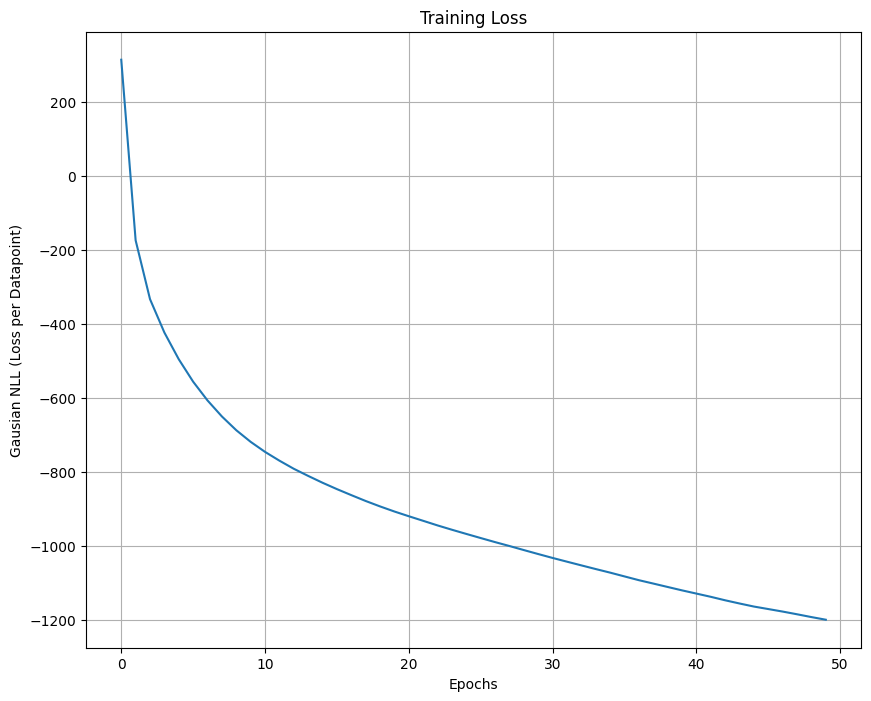

In [24]:
plt.figure(figsize=(10,8))
plt.plot(range(epochs),train_loss_history)
plt.xlabel('Epochs')
plt.ylabel('Gausian NLL (Loss per Datapoint)')
plt.title('Training Loss')
plt.grid(True)

In [25]:
test_idx = int(1e6)
available_ground_truth = dataset[test_idx:test_idx+2].reshape(-1)
available_ground_truth = available_ground_truth.astype(np.float32)
print(available_ground_truth.shape)

(400,)


In [28]:
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
checkpoint=torch.load("best_continuous_nade.pt",map_location=device)
model=ContinuousNADE(input_dim=400,hidden_dim=1000).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

ContinuousNADE()

In [ ]:
'''
base_model = model.module if isinstance(model, nn.DataParallel) else model
base_model.eval()

generate_samples = int(5e4)
generated_time_window_samples = []

with torch.no_grad():
    for i in range(generate_samples):
        generated_time_window_samples.append(base_model.sample().cpu())
        current_count = i + 1
        if current_count % 1000 == 0:
            print(current_count, "/", generate_samples, "have been generated")
'''

In [49]:
samples=model.sample_batch(int(4e5))
print(samples.shape)

torch.Size([400000, 400])


In [50]:
generated_time_window_samples = samples.detach().cpu().numpy().astype(np.float32)

print(generated_time_window_samples.shape)

np.save("generated_time_window_samples.npy", generated_time_window_samples)

(400000, 400)


In [51]:
candidates = torch.from_numpy(generated_time_window_samples).float().to(device)
mu_tensor = torch.tensor(train_dataset.mean, device=candidates.device)
std_tensor = torch.tensor(train_dataset.std, device=candidates.device)
unnormalized_candidates = (candidates * std_tensor) + mu_tensor
candidate_tails = unnormalized_candidates[:, :200]
candidate_heads = unnormalized_candidates[:, 200:]

In [76]:
forecast_horizon = int(4e4)   #Number of Sample
forecasted_trajectory = []
current_state = torch.tensor(available_ground_truth[200:], dtype=torch.float32).to(device)

In [77]:
for i in range(forecast_horizon):
    distances = torch.norm(candidate_tails - current_state, dim=1)
    best_index = torch.argmin(distances)
    winning_forecast = candidate_heads[best_index]
    forecasted_trajectory.append(winning_forecast.cpu().numpy())
    current_state = winning_forecast

In [78]:
forecasted_trajectory = np.array(forecasted_trajectory)
print(f"Forecasting complete! Shape: {forecasted_trajectory.shape}")

Forecasting complete! Shape: (40000, 200)


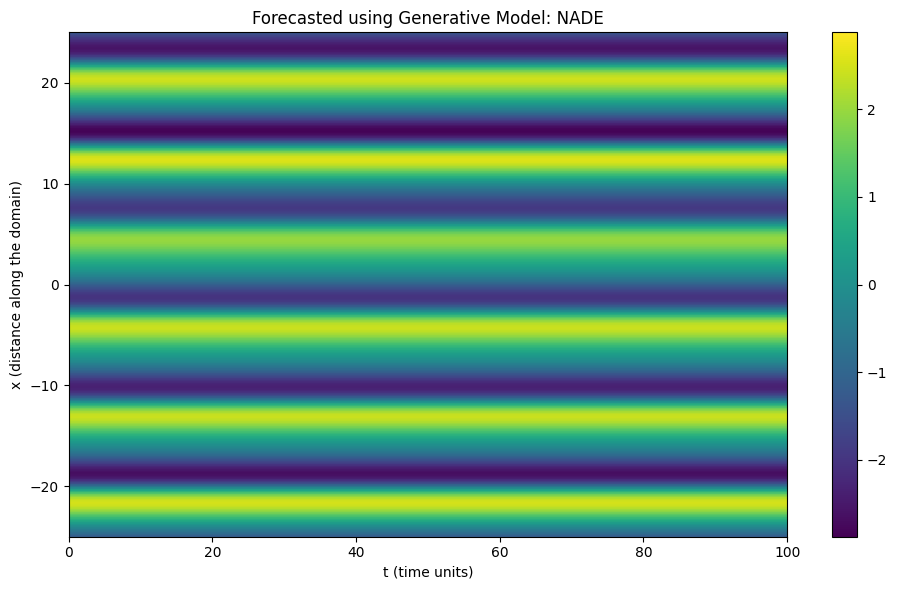

In [79]:
data_slice=forecasted_trajectory[:1000,:]
plot_data=data_slice.T

dt=0.1
x_min,x_max=-25,25

t_start = 0
t_end = data_slice.shape[0] * dt 

plt.figure(figsize=(10,6))
plt.imshow(plot_data,
           aspect='auto',
           origin='lower',
           extent=[t_start,t_end,x_min,x_max],
           cmap='viridis',
           vmin=-2.88,
           vmax=2.88)

plt.title("Forecasted using Generative Model: NADE")
plt.xlabel("t (time units)")
plt.ylabel("x (distance along the domain)")
plt.xticks([0, 20, 40, 60, 80, 100])
plt.tight_layout()
plt.colorbar()
plt.show()

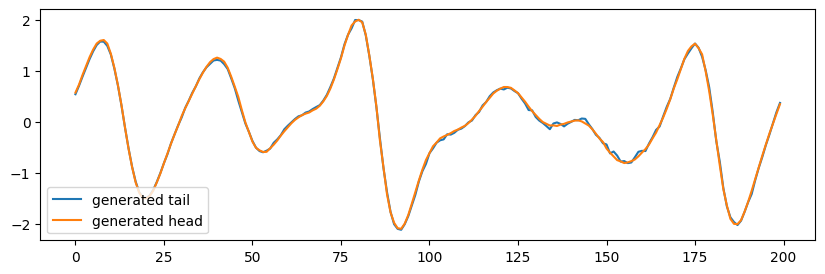

In [80]:
sample_id = int(1e5)

plt.figure(figsize=(10,3))
plt.plot(generated_time_window_samples[sample_id, :200], label="generated tail")
plt.plot(generated_time_window_samples[sample_id, 200:], label="generated head")
plt.legend()
plt.show()

In [81]:
# real one-step change
real_deltas = np.linalg.norm(dataset[1:10000] - dataset[:9999], axis=1)

# generated one-step change
gen_deltas = np.linalg.norm(
    generated_time_window_samples[:, 200:] - generated_time_window_samples[:, :200],
    axis=1
)

print("Real delta mean:", real_deltas.mean())
print("Generated delta mean:", gen_deltas.mean())

print("Real delta std:", real_deltas.std())
print("Generated delta std:", gen_deltas.std())

Real delta mean: 0.4511355896457978
Generated delta mean: 1.1999687
Real delta std: 0.13572370279568335
Generated delta std: 2.9422243


# Distribution Adherence Plots

In [86]:
idx = int(1e6)

all_data = dataset[:]
train_data = dataset[:idx:]
truth_data = dataset[idx:idx+forecast_horizon,:]
pred_data = forecasted_trajectory[:]


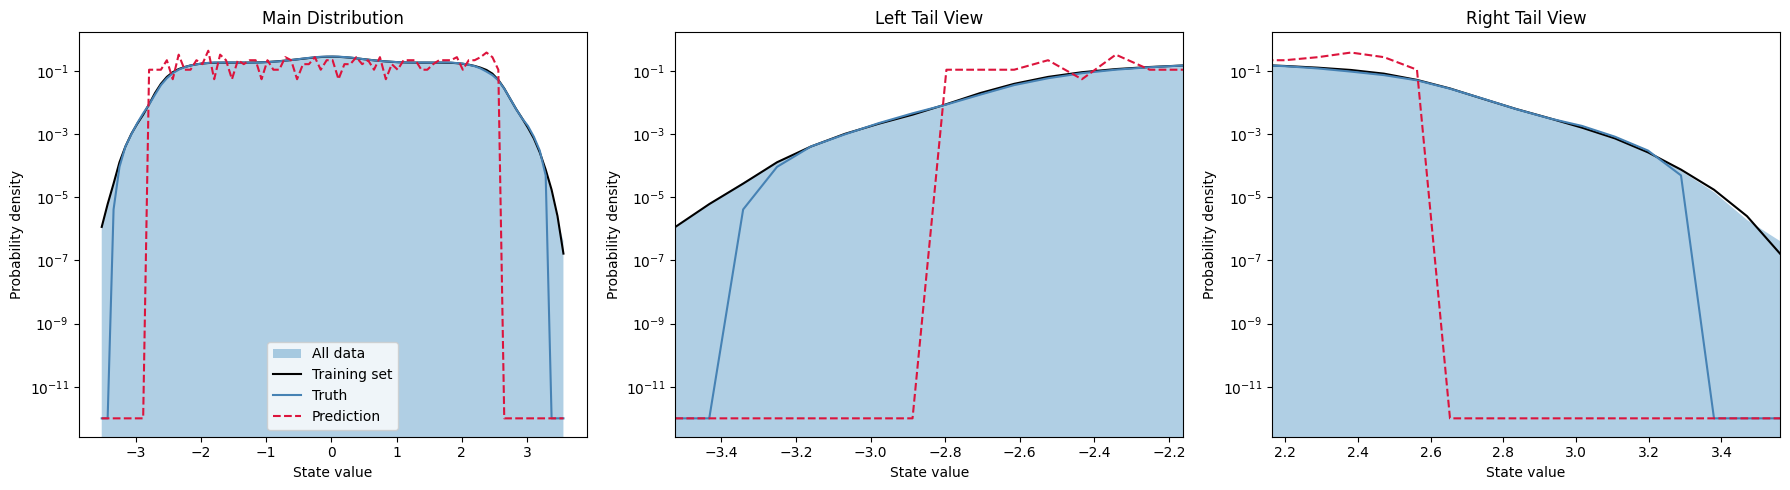

In [87]:
all_vals = np.asarray(all_data).reshape(-1)
train_vals = np.asarray(train_data).reshape(-1)
truth_vals = np.asarray(truth_data).reshape(-1)
pred_vals = np.asarray(pred_data).reshape(-1)

bins = np.linspace(
    min(all_vals.min(), train_vals.min(), truth_vals.min(), pred_vals.min()),
    max(all_vals.max(), train_vals.max(), truth_vals.max(), pred_vals.max()),
    80
)

eps = 1e-12

all_hist, edges = np.histogram(all_vals, bins=bins, density=True)
train_hist, _ = np.histogram(train_vals, bins=bins, density=True)
truth_hist, _ = np.histogram(truth_vals, bins=bins, density=True)
pred_hist, _ = np.histogram(pred_vals, bins=bins, density=True)

centers = 0.5 * (edges[:-1] + edges[1:])

all_hist = all_hist + eps
train_hist = train_hist + eps
truth_hist = truth_hist + eps
pred_hist = pred_hist + eps

left_limit = np.percentile(all_vals, 5)
right_limit = np.percentile(all_vals, 95)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Main plot
ax = axes[0]
ax.fill_between(centers, all_hist, alpha=0.35, label="All data")
ax.plot(centers, train_hist, color="black", linewidth=1.5, label="Training set")
ax.plot(centers, truth_hist, color="steelblue", linewidth=1.5, label="Truth")
ax.plot(centers, pred_hist, color="crimson", linestyle="--", linewidth=1.5, label="Prediction")
ax.set_yscale("log")
ax.set_xlabel("State value")
ax.set_ylabel("Probability density")
ax.set_title("Main Distribution")
ax.legend()

# Left tail
ax = axes[1]
ax.fill_between(centers, all_hist, alpha=0.35)
ax.plot(centers, train_hist, color="black", linewidth=1.5)
ax.plot(centers, truth_hist, color="steelblue", linewidth=1.5)
ax.plot(centers, pred_hist, color="crimson", linestyle="--", linewidth=1.5)
ax.set_yscale("log")
ax.set_xlim(centers.min(), left_limit)
ax.set_xlabel("State value")
ax.set_ylabel("Probability density")
ax.set_title("Left Tail View")

# Right tail
ax = axes[2]
ax.fill_between(centers, all_hist, alpha=0.35)
ax.plot(centers, train_hist, color="black", linewidth=1.5)
ax.plot(centers, truth_hist, color="steelblue", linewidth=1.5)
ax.plot(centers, pred_hist, color="crimson", linestyle="--", linewidth=1.5)
ax.set_yscale("log")
ax.set_xlim(right_limit, centers.max())
ax.set_xlabel("State value")
ax.set_ylabel("Probability density")
ax.set_title("Right Tail View")

plt.tight_layout()
plt.show()